In [1]:
from __future__ import print_function

import os
import sys
import csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.activations import relu
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers

from tensorflow.keras.datasets import imdb

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("Packages Loaded")

Packages Loaded


We will be working with the IMDB data from keras for this lab. The data is already enocded so I wanted to show an example of what text data looks like before it gets encoded. Below is the stanford sentiment treebank data broken up into its data and the sentiment values.

I wanted to use a more complex dataset for this but the time constraints due to COV-19 have made that difficult. 

In [2]:
# Here I import it as a table using pandas and I have to set the column names manually.
data = pd.read_table('dictionary.txt',index_col=False, header=None)
data.columns = ['Phrase|Index']
# Most corpus text data is set up in a way that has delimiters to seperate the data from the indexs. The delimiter for this data is |
data = data['Phrase|Index'].str.split('|', expand=True)
# The code above split the strings into an id index and the actual data.
data = data.rename(columns={0: 'Phrase', 1: 'phrase_ids'})
data

,Phrase,phrase_ids
0,!,0
1,! ',22935
2,! '',18235
3,! Alas,179257
4,! Brilliant,22936
...,...,...
239227,zoning ordinances to protect your community fr...,220441
239228,zzzzzzzzz,179256
239229,élan,220442
239230,É,220443


In [3]:
# I then do the same steps for the sentiment value labels for this data.
labels = pd.read_table('sentiment_labels.txt')
labels = labels['phrase ids|sentiment values'].str.split('|', expand=True)
labels = labels.rename(columns={0: 'phrase_ids', 1: 'sentiment_values'})
labels

,phrase_ids,sentiment_values
0,0,0.5
1,1,0.5
2,2,0.44444
3,3,0.5
4,4,0.42708
...,...,...
239227,239227,0.36111
239228,239228,0.38889
239229,239229,0.33333
239230,239230,0.88889


In [4]:
# Here I merged the data into one table using a SQL like join command which combines the tables based on the 'phrase_ids' column.
df = data.merge(labels, how='inner', on='phrase_ids')
# I then set the phrase ids as the index for the dataframe and drop the redundant id column.
df.index = df.phrase_ids
df = df.drop('phrase_ids', axis=1)
df

,Phrase,sentiment_values
phrase_ids,,
0,!,0.5
22935,! ',0.52778
18235,! '',0.5
179257,! Alas,0.44444
22936,! Brilliant,0.86111
...,...,...
220441,zoning ordinances to protect your community fr...,0.13889
179256,zzzzzzzzz,0.19444
220442,élan,0.51389


The above process is very common and you should practice it yourself to get used to the process. I recommend (this isn't graded) to do this yourself with the amazon review data here: http://jmcauley.ucsd.edu/data/amazon/

In [5]:
# This is a pretrained embedder called GloVe. here I had to use the 'quoting=csv.QUOTE_NONE' because the text file included quotation marks.
embed = pd.read_table('glove.6B.100d.txt', engine='python', encoding='utf-8', error_bad_lines=False, header=None, quoting=csv.QUOTE_NONE)

In [6]:
# We see here that the data has two components to it. The beginning of every string is the word that got embedded and it is followed by a long list of numbers.
# These numbers are how the machine learning model trains on data. Normally you will automatically create a trainable embedding in your model (like we will today).
# There are times when you will want to use a pretrained embedding like GloVe to speed up computation time. So its good to know how to use them.
# You can find detailed instructions on how to use GloVe and other pre-trained embeddings in the keras and tensorflow docs.
embed

,0
0,the -0.038194 -0.24487 0.72812 -0.39961 0.0831...
1,", -0.10767 0.11053 0.59812 -0.54361 0.67396 0...."
2,. -0.33979 0.20941 0.46348 -0.64792 -0.38377 0...
3,of -0.1529 -0.24279 0.89837 0.16996 0.53516 0....
4,to -0.1897 0.050024 0.19084 -0.049184 -0.08973...
...,...
399995,chanty -0.15577 -0.049188 -0.064377 0.2236 -0....
399996,kronik -0.094426 0.14725 -0.15739 0.071966 -0....
399997,rolonda 0.36088 -0.16919 -0.32704 0.098332 -0....
399998,zsombor -0.10461 -0.5047 -0.49331 0.13516 -0.3...


So now lets get into the data we are working with today. In the last couple of labs we used CNNs and ResNets a lot. This time we are going to compare CNNs with LSTMs for the purpose of classifying text. The data is setup so that a '0 label' is a negative review and a '1 label' is a postive review.

We want to create machine learning models to automatically detect whether or not a review is positive. This has wide applications for both industry and research and has been extensively researched since 2014. 

In [2]:
np_load_old = np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
# Lets load our data. We will limit the number of words to 5,000 as that is how the data is setup.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)
np.load = np_load_old

# We pad the data because not all sentences in our data are the same length. We want to use a number that is larger than our largest data. Here I will choose 400.
x_train = sequence.pad_sequences(x_train, maxlen=400)
x_test = sequence.pad_sequences(x_test, maxlen=400)

Train on 25000 samples, validate on 25000 samples
Epoch 1/10
25000/25000 [==============================] - 137s 5ms/step - loss: 0.6414 - acc: 0.6786 - val_loss: 0.6637 - val_acc: 0.5086
Epoch 2/10
25000/25000 [==============================] - 205s 8ms/step - loss: 0.3403 - acc: 0.8562 - val_loss: 0.4451 - val_acc: 0.8546
Epoch 3/10
25000/25000 [==============================] - 176s 7ms/step - loss: 0.2508 - acc: 0.8982 - val_loss: 0.2995 - val_acc: 0.8790
Epoch 4/10
25000/25000 [==============================] - 198s 8ms/step - loss: 0.1905 - acc: 0.9252 - val_loss: 0.3017 - val_acc: 0.8784
Epoch 5/10
25000/25000 [==============================] - 151s 6ms/step - loss: 0.1558 - acc: 0.9416 - val_loss: 0.3326 - val_acc: 0.8806
Epoch 6/10
25000/25000 [==============================] - 151s 6ms/step - loss: 0.1256 - acc: 0.9516 - val_loss: 0.3411 - val_acc: 0.8793
Epoch 7/10
25000/25000 [==============================] - 156s 6ms/step - loss: 0.0971 - acc: 0.9654 - val_loss: 0.3775 - 

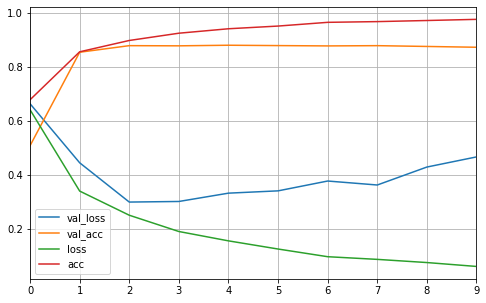

In [4]:
# Lets start with a very simple 1D CNN model. We will use this as our baseline for everything else in this lab.
model = Sequential()

# This embedding is a trainable parameter. We aren't using GloVE for this model.
model.add(Embedding(5000,50,input_length=400))
model.add(Dropout(0.2))

# There isn't much of a difference with how 1D and 2D CNNs work. They still use filters and scan the data.
# we will use a similar model as our 2D CNN with the adition of an embedding layer at the beginning.
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(GlobalMaxPooling1D())

model.add(Dense(512))
model.add(Dropout(0.5))
model.add(Activation('relu'))

# We will use a sigmoid and a 1 neuron dense output since our data is binary.
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='Nadam', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

#### How well is this model doing? Is it overfitting? If so how could you fix this since we are already applying BatchNorm and dropout?

Train on 25000 samples, validate on 25000 samples
Epoch 1/10
25000/25000 [==============================] - 104s 4ms/step - loss: 1.0513 - acc: 0.5120 - val_loss: 0.7126 - val_acc: 0.5000
Epoch 2/10
25000/25000 [==============================] - 99s 4ms/step - loss: 0.7069 - acc: 0.4959 - val_loss: 0.7086 - val_acc: 0.5000
Epoch 3/10
25000/25000 [==============================] - 100s 4ms/step - loss: 0.6398 - acc: 0.6523 - val_loss: 0.5210 - val_acc: 0.8055
Epoch 4/10
25000/25000 [==============================] - 99s 4ms/step - loss: 0.4566 - acc: 0.8207 - val_loss: 0.3878 - val_acc: 0.8626
Epoch 5/10
25000/25000 [==============================] - 100s 4ms/step - loss: 0.3736 - acc: 0.8654 - val_loss: 0.3335 - val_acc: 0.8808
Epoch 6/10
25000/25000 [==============================] - 103s 4ms/step - loss: 0.3268 - acc: 0.8887 - val_loss: 0.3130 - val_acc: 0.8862
Epoch 7/10
25000/25000 [==============================] - 101s 4ms/step - loss: 0.2945 - acc: 0.9022 - val_loss: 0.3119 - va

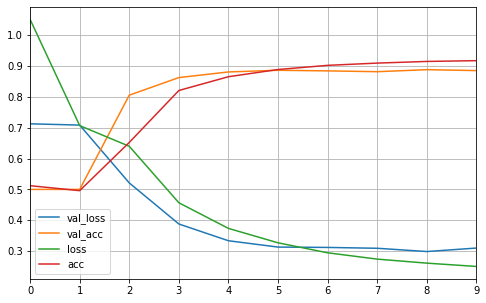

In [12]:
# Try and apply those fixes here. Can you make a baseline that doesn't overfit? What worked best.
model = Sequential()
model.add(Embedding(5000,50,input_length=400))
model.add(Dropout(0.6))

# There isn't much of a difference with how 1D and 2D CNNs work. They still use filters and scan the data.
# we will use a similar model as our 2D CNN with the adition of an embedding layer at the beginning.
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(GlobalMaxPooling1D())


model.add(Dense(512))
model.add(Dropout(0.6))
model.add(Activation('relu'))

# We will use a sigmoid and a 1 neuron dense output since our data is binary.
model.add(Dense(1, kernel_regularizer=regularizers.l1_l2(l1=0.05, l2=0.05)))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='Nadam', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 25000 samples, validate on 25000 samples
Epoch 1/10
25000/25000 [==============================] - 522s 21ms/step - loss: 8.0320 - acc: 0.5003 - val_loss: 0.9472 - val_acc: 0.5000
Epoch 2/10
25000/25000 [==============================] - 520s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 1.0300 - val_acc: 0.5007
Epoch 3/10
25000/25000 [==============================] - 522s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 8.0522 - val_acc: 0.5000
Epoch 4/10
25000/25000 [==============================] - 521s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 8.0590 - val_acc: 0.5000
Epoch 5/10
25000/25000 [==============================] - 522s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 8.0590 - val_acc: 0.5000
Epoch 6/10
25000/25000 [==============================] - 522s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 8.0590 - val_acc: 0.5000
Epoch 7/10
25000/25000 [==============================] - 524s 21ms/step - loss: 8.0590 - acc: 0.5000 - val_loss: 8.

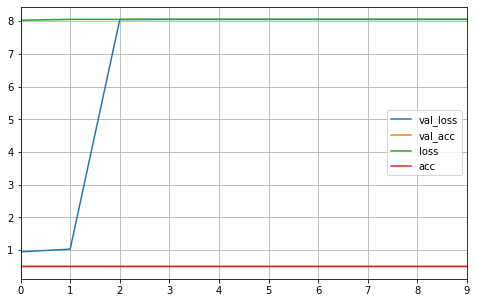

In [15]:
# Now we will make the network more complex by adding more filters to the data. How did this affect training?
model = Sequential()
model.add(Embedding(5000,50,input_length=400))
model.add(Dropout(0.2))

model.add(Conv1D(250,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(Conv1D(250,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(GlobalMaxPooling1D())

model.add(Dense(512))
model.add(Dropout(0.5))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='Nadam', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 25000 samples, validate on 25000 samples
Epoch 1/10
25000/25000 [==============================] - 146s 6ms/step - loss: 0.6136 - acc: 0.6885 - val_loss: 0.6514 - val_acc: 0.6862
Epoch 2/10
25000/25000 [==============================] - 141s 6ms/step - loss: 0.3276 - acc: 0.8606 - val_loss: 0.4358 - val_acc: 0.8725
Epoch 3/10
25000/25000 [==============================] - 139s 6ms/step - loss: 0.2511 - acc: 0.8960 - val_loss: 0.3021 - val_acc: 0.8740
Epoch 4/10
25000/25000 [==============================] - 141s 6ms/step - loss: 0.1939 - acc: 0.9259 - val_loss: 0.3142 - val_acc: 0.8760
Epoch 5/10
25000/25000 [==============================] - 142s 6ms/step - loss: 0.1539 - acc: 0.9410 - val_loss: 0.3713 - val_acc: 0.8644
Epoch 6/10
25000/25000 [==============================] - 140s 6ms/step - loss: 0.1225 - acc: 0.9529 - val_loss: 0.3666 - val_acc: 0.8760
Epoch 7/10
25000/25000 [==============================] - 139s 6ms/step - loss: 0.1048 - acc: 0.9608 - val_loss: 0.4224 - 

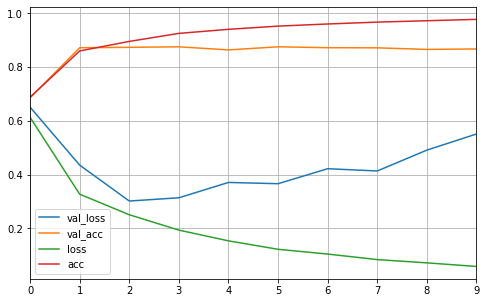

In [14]:
# Now lets add more CNN and BatchNorm layers to the network. Did this have the same affect as 2D CNNs from lab 5?
model = Sequential()
model.add(Embedding(5000,50,input_length=400))
model.add(Dropout(0.2))

model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(Conv1D(64,3,padding='valid',activation='relu',strides=1))
model.add(BatchNormalization())
model.add(GlobalMaxPooling1D())

model.add(Dense(512))
model.add(Dropout(0.5))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='Nadam', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=(x_test, y_test))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

#### Do 1D CNNs and 2D CNNs behave the same from the changes we are making?

Now lets look at some LSTMs. LSTMs and RNNs in general were the racehorse of deep learning from 2014-2016. Now they have drastically fallen off of favor in the DL community. The questions we want to answer in this lab are: Why do you think this is? Do you think it was a mistake to stray away from RNNs? What changes do you think we could make to make them better or should we just drop them all together?

The resources to learn more about this debate can be found here: https://towardsdatascience.com/the-fall-of-rnn-lstm-2d1594c74ce0

and here: https://towardsdatascience.com/memory-attention-sequences-37456d271992

and here: https://towardsdatascience.com/visual-attention-model-in-deep-learning-708813c2912c

These are optional readings but they serve to give you a firm foundation on the knowledge of current deep learning thought. Feel free to answer the above questions after we train our LSTMs.

If you don't know anything about RNNs read this: http://karpathy.github.io/2015/05/21/rnn-effectiveness/

Train on 25000 samples, validate on 25000 samples
Epoch 1/5
25000/25000 [==============================] - 653s 26ms/step - loss: 0.5371 - acc: 0.7234 - val_loss: 0.4626 - val_acc: 0.7908
Epoch 2/5
25000/25000 [==============================] - 640s 26ms/step - loss: 0.4228 - acc: 0.8162 - val_loss: 0.4433 - val_acc: 0.8232
Epoch 3/5
25000/25000 [==============================] - 643s 26ms/step - loss: 0.3016 - acc: 0.8792 - val_loss: 0.3428 - val_acc: 0.8691
Epoch 4/5
25000/25000 [==============================] - 640s 26ms/step - loss: 0.2406 - acc: 0.9080 - val_loss: 0.3718 - val_acc: 0.8376
Epoch 5/5
25000/25000 [==============================] - 641s 26ms/step - loss: 0.1999 - acc: 0.9256 - val_loss: 0.3562 - val_acc: 0.8697


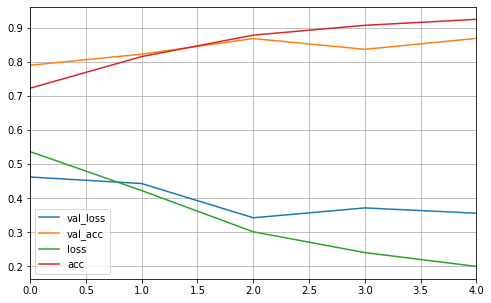

In [16]:
# Now we will make our LSTMs. We will use a smaller batch size as they take longer to train.
# We use the same embedding layers as we did for our CNNs.
model = Sequential()
model.add(Embedding(5000,50,input_length=400))

# Here we will add in our LSTM layers. They should be directly after the embedding layer.
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128))

# Now we will cast the LSTM output to a dense layer to sort it. If you haven't noticed, thick dense layers at the end of networks are how every model 'collects its thoughts'.
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile('Nadam', 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_data=[x_test, y_test])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

How does the basic LSTM compare to the 1D CNN? Is it overfitting as much? is it's testing accuracy better? 

In [ ]:
# Now lets add another LSTM layer to our model. Did that improve overfitting/accuracy?
model = Sequential()
model.add(Embedding(5000,50,input_length=400))

model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile('Nadam', 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_data=[x_test, y_test])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 25000 samples, validate on 25000 samples
Epoch 1/10
25000/25000 [==============================] - 1195s 48ms/step - loss: 0.6186 - acc: 0.6717 - val_loss: 0.6925 - val_acc: 0.5000
Epoch 2/10
25000/25000 [==============================] - 1286s 51ms/step - loss: 0.6767 - acc: 0.5544 - val_loss: 0.6937 - val_acc: 0.5008
Epoch 3/10
25000/25000 [==============================] - 1157s 46ms/step - loss: 0.6915 - acc: 0.5242 - val_loss: 0.6916 - val_acc: 0.5000
Epoch 4/10
25000/25000 [==============================] - 1287s 51ms/step - loss: 0.5693 - acc: 0.6928 - val_loss: 0.3648 - val_acc: 0.8514
Epoch 5/10
25000/25000 [==============================] - 1311s 52ms/step - loss: 0.3280 - acc: 0.8657 - val_loss: 0.4674 - val_acc: 0.8088
Epoch 6/10
25000/25000 [==============================] - 1320s 53ms/step - loss: 0.2721 - acc: 0.8924 - val_loss: 0.3755 - val_acc: 0.8392
Epoch 7/10
25000/25000 [==============================] - 1290s 52ms/step - loss: 0.2397 - acc: 0.9076 - val_l

Train on 25000 samples, validate on 25000 samples
Epoch 1/5
25000/25000 [==============================] - 2102s 84ms/step - loss: 0.6190 - acc: 0.6773 - val_loss: 0.4794 - val_acc: 0.7696
Epoch 2/5
25000/25000 [==============================] - 2051s 82ms/step - loss: 0.4766 - acc: 0.7844 - val_loss: 0.5355 - val_acc: 0.7255
Epoch 3/5
25000/25000 [==============================] - 2109s 84ms/step - loss: 0.6179 - acc: 0.5980 - val_loss: 0.6931 - val_acc: 0.5000
Epoch 4/5
25000/25000 [==============================] - 2189s 88ms/step - loss: 0.6933 - acc: 0.4982 - val_loss: 0.6931 - val_acc: 0.5000
Epoch 5/5
25000/25000 [==============================] - 2274s 91ms/step - loss: 0.6932 - acc: 0.4986 - val_loss: 0.6931 - val_acc: 0.5000


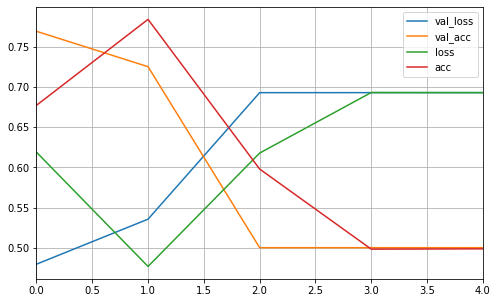

In [18]:
# Now lets use larger LSTM layers. What affect did that have? Why do you think that is based off of your knowledge of RNNs.
model = Sequential()
model.add(Embedding(5000,50,input_length=400))

# Here we will add in our LSTM layers. They should be directly after the embedding layer.
model.add(LSTM(256, return_sequences=True))
model.add(LSTM(256))

# Now we will cast the LSTM output to a dense layer to sort it. If you haven't noticed, thick dense layers at the end of networks are how every model 'collects its thoughts'.
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile('Nadam', 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_data=[x_test, y_test])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Train on 25000 samples, validate on 25000 samples
Epoch 1/5
25000/25000 [==============================] - 1740s 70ms/step - loss: 0.5675 - acc: 0.7148 - val_loss: 0.4679 - val_acc: 0.8019
Epoch 2/5
25000/25000 [==============================] - 1702s 68ms/step - loss: 0.3495 - acc: 0.8512 - val_loss: 0.3795 - val_acc: 0.8492
Epoch 3/5
25000/25000 [==============================] - 1730s 69ms/step - loss: 0.2787 - acc: 0.8889 - val_loss: 0.3612 - val_acc: 0.8664
Epoch 4/5
25000/25000 [==============================] - 1723s 69ms/step - loss: 0.2346 - acc: 0.9076 - val_loss: 0.4083 - val_acc: 0.8404
Epoch 5/5
25000/25000 [==============================] - 1721s 69ms/step - loss: 0.2041 - acc: 0.9217 - val_loss: 0.3298 - val_acc: 0.8649


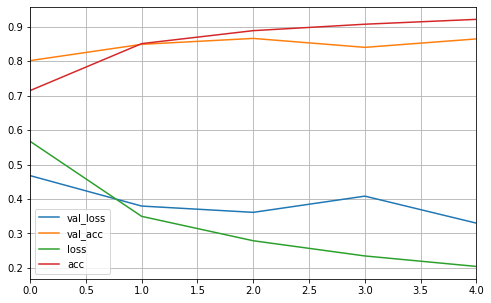

In [19]:
# Now lets add Bi-directional layers to each of our RNNs. These make the model learn the data scanning both forwards and backwards. 
# Here is a detailed description: https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

model = Sequential()
model.add(Embedding(5000,50,input_length=400))

# Here we will add in our LSTM layers. They should be directly after the embedding layer.
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(128)))

# Now we will cast the LSTM output to a dense layer to sort it. If you haven't noticed, thick dense layers at the end of networks are how every model 'collects its thoughts'.
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile('Nadam', 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_data=[x_test, y_test])
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

#How does this affect training/overfitting? 

#### Can you think of anyway to prevent overfitting in an LSTM? got down some ideas and feel free to try them. If you get a signifcant result post it to the discussion board for the rest of the class!

Now that we have looked at the classical examples of 1D CNNs and LSTMs, what do you think are the potential tradeoffs between using each one? Which one makes more sense to use and is there a reason to use LSTMs or RNNs in general for sequential data?

If you are feeling brave and have the extra time I encourage you to impliment an attention layer for both the 1D CNN and bi-directional LSTM and see how much Attention helps. You can also use image attention layers to improve 2D CNNs!